# Phase 3: Model Training

This notebook trains 3 ML models:
1. **Risk Profile Classifier** - Predicts Aggressive/Moderate/Conservative
2. **Allocation Regressor** - Predicts equity% and bond%
3. **Total ETFs Regressor** - Predicts number of ETFs to hold

After training, we'll use the existing rule-based `assign_portfolio_numeric_aum()` for ticker selection.

## Step 1: Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports successful")

✅ Imports successful


## Step 2: Load Prepared Data

In [3]:
# Load training data
X_train = pd.read_csv('data/X_train.csv')
X_test = pd.read_csv('data/X_test.csv')

y1_train = pd.read_csv('data/y_train_profile.csv')['risk_profile']
y1_test = pd.read_csv('data/y_test_profile.csv')['risk_profile']

y2_train = pd.read_csv('data/y_train_allocation.csv')
y2_test = pd.read_csv('data/y_test_allocation.csv')

y3_train = pd.read_csv('data/y_train_etfs.csv')['total_etfs']
y3_test = pd.read_csv('data/y_test_etfs.csv')['total_etfs']

print("✅ Data loaded successfully")
print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nFeatures: {X_train.shape[1]}")
print(f"Feature names: {X_train.columns.tolist()[:5]}... (showing first 5)")

✅ Data loaded successfully

Training set size: 4000
Test set size: 1000

Features: 19
Feature names: ['age', 'HouseholdSize', 'income', 'horizon', 'InvestmentCapital']... (showing first 5)


## Step 3: Model 1 - Risk Profile Classifier

In [4]:
print("="*60)
print("MODEL 1: RISK PROFILE CLASSIFIER")
print("="*60)

# Check class distribution
print("\nTarget distribution (train):")
print(y1_train.value_counts())
print("\nPercentages:")
print(y1_train.value_counts(normalize=True) * 100)

MODEL 1: RISK PROFILE CLASSIFIER

Target distribution (train):
risk_profile
Moderate        1521
Aggressive      1257
Conservative    1222
Name: count, dtype: int64

Percentages:
risk_profile
Moderate        38.025
Aggressive      31.425
Conservative    30.550
Name: proportion, dtype: float64


In [5]:
# Train Random Forest Classifier
print("\n🔄 Training Random Forest Classifier...")

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_classifier.fit(X_train, y1_train)

print("\n✅ Training complete!")


🔄 Training Random Forest Classifier...

✅ Training complete!


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


In [6]:
# Make predictions
y1_train_pred = rf_classifier.predict(X_train)
y1_test_pred = rf_classifier.predict(X_test)

# Calculate metrics
train_acc = accuracy_score(y1_train, y1_train_pred)
test_acc = accuracy_score(y1_test, y1_test_pred)

print("\n📊 PERFORMANCE METRICS")
print("="*60)
print(f"Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y1_test, y1_test_pred, average=None)
classes = rf_classifier.classes_

print("\nPer-Class Metrics (Test Set):")
print("-" * 60)
for i, cls in enumerate(classes):
    print(f"{cls:15s} | Precision: {precision[i]:.3f} | Recall: {recall[i]:.3f} | F1: {f1[i]:.3f} | Support: {support[i]}")

# Macro averages
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y1_test, y1_test_pred, average='macro')
print("-" * 60)
print(f"{'Macro Avg':15s} | Precision: {macro_precision:.3f} | Recall: {macro_recall:.3f} | F1: {macro_f1:.3f}")


📊 PERFORMANCE METRICS
Training Accuracy: 0.7060 (70.60%)
Test Accuracy: 0.4600 (46.00%)

Per-Class Metrics (Test Set):
------------------------------------------------------------
Aggressive      | Precision: 0.495 | Recall: 0.487 | F1: 0.491 | Support: 314
Conservative    | Precision: 0.477 | Recall: 0.376 | F1: 0.420 | Support: 306
Moderate        | Precision: 0.427 | Recall: 0.505 | F1: 0.463 | Support: 380
------------------------------------------------------------
Macro Avg       | Precision: 0.466 | Recall: 0.456 | F1: 0.458


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


FileNotFoundError: [Errno 2] No such file or directory: '../evaluation_reports/confusion_matrix_risk_profile.png'

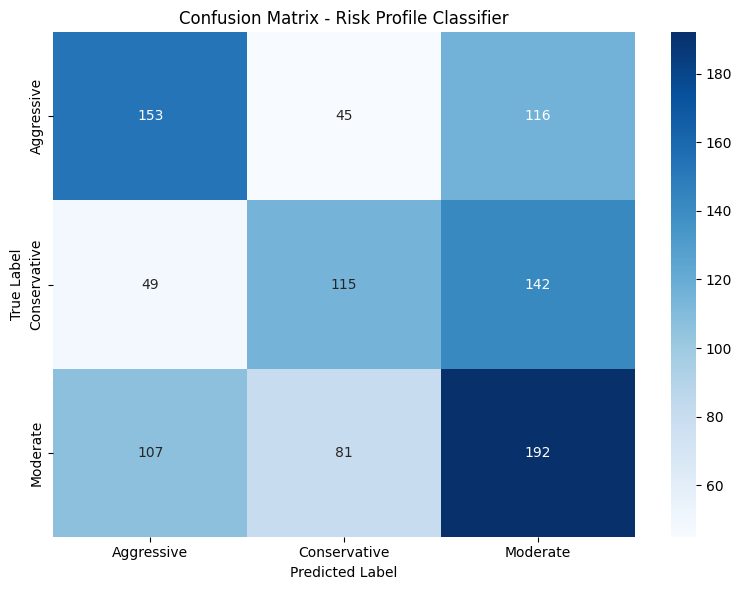

In [7]:
# Confusion Matrix
cm = confusion_matrix(y1_test, y1_test_pred, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - Risk Profile Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../evaluation_reports/confusion_matrix_risk_profile.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrix saved to: evaluation_reports/confusion_matrix_risk_profile.png")


Top 10 Most Important Features:
                        feature  importance
0                           age    0.167508
2                        income    0.149745
4             InvestmentCapital    0.149496
5                    experience    0.141127
3                       horizon    0.123893
15           risk_tolerance_Low    0.047951
1                 HouseholdSize    0.040781
6                   Gender_Male    0.023402
18  FinancialInvolvement_Medium    0.022802
7         Education_High school    0.019505


FileNotFoundError: [Errno 2] No such file or directory: '../evaluation_reports/feature_importance_risk_profile.png'

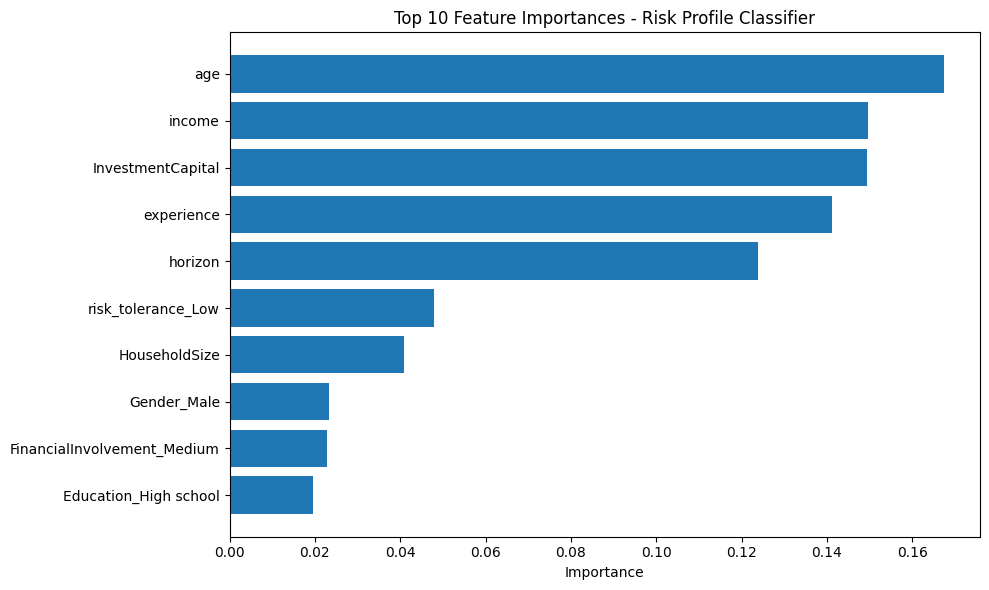

In [8]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['feature'], feature_importance.head(10)['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances - Risk Profile Classifier')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../evaluation_reports/feature_importance_risk_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Model 2 - Allocation Regressor

In [9]:
print("="*60)
print("MODEL 2: ALLOCATION REGRESSOR (Multi-Output)")
print("="*60)

# Check target distribution
print("\nTarget statistics (train):")
print(y2_train.describe())

MODEL 2: ALLOCATION REGRESSOR (Multi-Output)

Target statistics (train):
        equity_pct     bond_pct
count  4000.000000  4000.000000
mean      0.568139     0.331784
std       0.181869     0.182166
min       0.217555     0.010099
25%       0.386232     0.134395
50%       0.550726     0.348866
75%       0.764808     0.515291
max       0.935319     0.656095


In [10]:
# Train Multi-Output Regressor
print("\n🔄 Training Multi-Output Random Forest Regressor...")

allocation_regressor = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
)

allocation_regressor.fit(X_train, y2_train)

print("\n✅ Training complete!")


🔄 Training Multi-Output Random Forest Regressor...

✅ Training complete!


In [11]:
# Make predictions
y2_train_pred = allocation_regressor.predict(X_train)
y2_test_pred = allocation_regressor.predict(X_test)

# Convert to DataFrame for easier handling
y2_train_pred_df = pd.DataFrame(y2_train_pred, columns=['equity_pct', 'bond_pct'])
y2_test_pred_df = pd.DataFrame(y2_test_pred, columns=['equity_pct', 'bond_pct'])

print("\n📊 PERFORMANCE METRICS")
print("="*60)

# Metrics for each output
for i, col in enumerate(['equity_pct', 'bond_pct']):
    train_mae = mean_absolute_error(y2_train[col], y2_train_pred[:, i])
    test_mae = mean_absolute_error(y2_test[col], y2_test_pred[:, i])
    
    train_rmse = np.sqrt(mean_squared_error(y2_train[col], y2_train_pred[:, i]))
    test_rmse = np.sqrt(mean_squared_error(y2_test[col], y2_test_pred[:, i]))
    
    train_r2 = r2_score(y2_train[col], y2_train_pred[:, i])
    test_r2 = r2_score(y2_test[col], y2_test_pred[:, i])
    
    print(f"\n{col.upper()}:")
    print(f"  Train MAE: {train_mae:.4f} ({train_mae*100:.2f}% error)")
    print(f"  Test MAE:  {test_mae:.4f} ({test_mae*100:.2f}% error)")
    print(f"  Train RMSE: {train_rmse:.4f}")
    print(f"  Test RMSE:  {test_rmse:.4f}")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²:  {test_r2:.4f}")


📊 PERFORMANCE METRICS

EQUITY_PCT:
  Train MAE: 0.1056 (10.56% error)
  Test MAE:  0.1487 (14.87% error)
  Train RMSE: 0.1256
  Test RMSE:  0.1764
  Train R²: 0.5232
  Test R²:  0.0630

BOND_PCT:
  Train MAE: 0.1059 (10.59% error)
  Test MAE:  0.1485 (14.85% error)
  Train RMSE: 0.1260
  Test RMSE:  0.1766
  Train R²: 0.5211
  Test R²:  0.0617


FileNotFoundError: [Errno 2] No such file or directory: '../evaluation_reports/allocation_predictions.png'

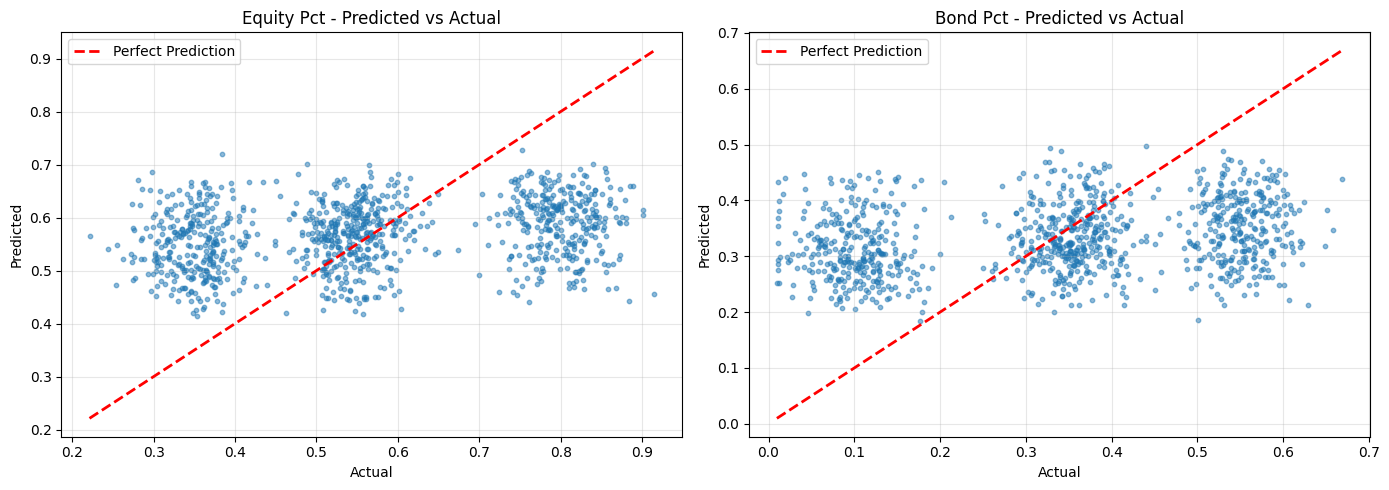

In [12]:
# Scatter plots: Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['equity_pct', 'bond_pct']):
    axes[i].scatter(y2_test[col], y2_test_pred[:, i], alpha=0.5, s=10)
    axes[i].plot([y2_test[col].min(), y2_test[col].max()], 
                 [y2_test[col].min(), y2_test[col].max()], 
                 'r--', lw=2, label='Perfect Prediction')
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
    axes[i].set_title(f'{col.replace("_", " ").title()} - Predicted vs Actual')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../evaluation_reports/allocation_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Scatter plots saved to: evaluation_reports/allocation_predictions.png")

## Step 5: Model 3 - Total ETFs Regressor

In [13]:
print("="*60)
print("MODEL 3: TOTAL ETFs REGRESSOR")
print("="*60)

# Check target distribution
print("\nTarget statistics (train):")
print(y3_train.describe())
print("\nDistribution:")
print(y3_train.value_counts().sort_index())

MODEL 3: TOTAL ETFs REGRESSOR

Target statistics (train):
count    4000.000000
mean        9.807000
std         1.277756
min         7.000000
25%         9.000000
50%        10.000000
75%        11.000000
max        13.000000
Name: total_etfs, dtype: float64

Distribution:
total_etfs
7       95
8      559
9      998
10    1149
11     819
12     330
13      50
Name: count, dtype: int64


In [14]:
# Train Random Forest Regressor
print("\n🔄 Training Random Forest Regressor...")

etf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

etf_regressor.fit(X_train, y3_train)

print("\n✅ Training complete!")


🔄 Training Random Forest Regressor...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s



✅ Training complete!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.2s finished


In [15]:
# Make predictions
y3_train_pred = etf_regressor.predict(X_train)
y3_test_pred = etf_regressor.predict(X_test)

# Round to nearest integer and clip to valid range [7, 13]
y3_train_pred_rounded = np.clip(np.round(y3_train_pred), 7, 13).astype(int)
y3_test_pred_rounded = np.clip(np.round(y3_test_pred), 7, 13).astype(int)

print("\n📊 PERFORMANCE METRICS")
print("="*60)

# Raw predictions (before rounding)
train_mae = mean_absolute_error(y3_train, y3_train_pred)
test_mae = mean_absolute_error(y3_test, y3_test_pred)

train_rmse = np.sqrt(mean_squared_error(y3_train, y3_train_pred))
test_rmse = np.sqrt(mean_squared_error(y3_test, y3_test_pred))

train_r2 = r2_score(y3_train, y3_train_pred)
test_r2 = r2_score(y3_test, y3_test_pred)

print("\nRaw Predictions (continuous):")
print(f"  Train MAE: {train_mae:.4f} ETFs")
print(f"  Test MAE:  {test_mae:.4f} ETFs")
print(f"  Train RMSE: {train_rmse:.4f}")
print(f"  Test RMSE:  {test_rmse:.4f}")
print(f"  Train R²: {train_r2:.4f}")
print(f"  Test R²:  {test_r2:.4f}")

# Rounded predictions (after rounding to integer)
train_mae_rounded = mean_absolute_error(y3_train, y3_train_pred_rounded)
test_mae_rounded = mean_absolute_error(y3_test, y3_test_pred_rounded)

print("\nRounded Predictions (integer):")
print(f"  Train MAE: {train_mae_rounded:.4f} ETFs")
print(f"  Test MAE:  {test_mae_rounded:.4f} ETFs")

# Exact match accuracy
train_exact = (y3_train == y3_train_pred_rounded).mean()
test_exact = (y3_test == y3_test_pred_rounded).mean()

print(f"\nExact Match Accuracy:")
print(f"  Train: {train_exact:.4f} ({train_exact*100:.2f}%)")
print(f"  Test:  {test_exact:.4f} ({test_exact*100:.2f}%)")


📊 PERFORMANCE METRICS

Raw Predictions (continuous):
  Train MAE: 0.8578 ETFs
  Test MAE:  1.0555 ETFs
  Train RMSE: 1.0622
  Test RMSE:  1.2862
  Train R²: 0.3087
  Test R²:  0.0090

Rounded Predictions (integer):
  Train MAE: 0.8472 ETFs
  Test MAE:  1.0290 ETFs

Exact Match Accuracy:
  Train: 0.3382 (33.83%)
  Test:  0.2650 (26.50%)


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


FileNotFoundError: [Errno 2] No such file or directory: '../evaluation_reports/etf_count_distribution.png'

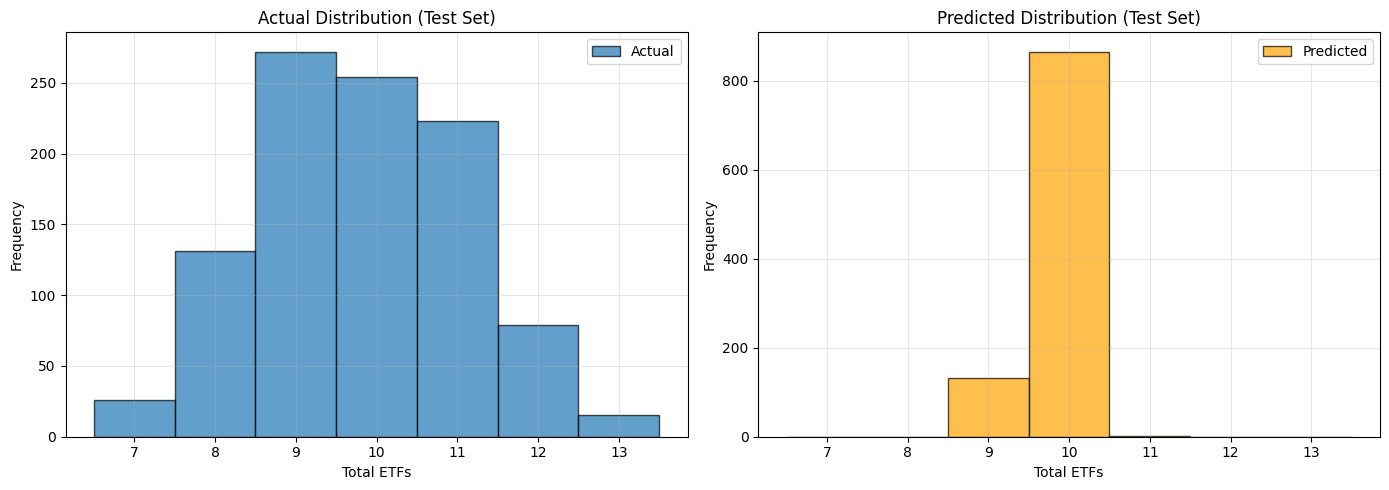

In [16]:
# Distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual distribution
axes[0].hist(y3_test, bins=np.arange(6.5, 14.5, 1), alpha=0.7, label='Actual', edgecolor='black')
axes[0].set_xlabel('Total ETFs')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Actual Distribution (Test Set)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Predicted distribution
axes[1].hist(y3_test_pred_rounded, bins=np.arange(6.5, 14.5, 1), alpha=0.7, label='Predicted', color='orange', edgecolor='black')
axes[1].set_xlabel('Total ETFs')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Predicted Distribution (Test Set)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../evaluation_reports/etf_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Distribution plots saved to: evaluation_reports/etf_count_distribution.png")

## Step 6: Save Trained Models

In [17]:
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save models
joblib.dump(rf_classifier, '../models/risk_profile_classifier.pkl')
joblib.dump(allocation_regressor, '../models/allocation_regressor.pkl')
joblib.dump(etf_regressor, '../models/etf_count_regressor.pkl')

print("✅ Models saved successfully!")
print("\nSaved files:")
print("  - models/risk_profile_classifier.pkl")
print("  - models/allocation_regressor.pkl")
print("  - models/etf_count_regressor.pkl")

✅ Models saved successfully!

Saved files:
  - models/risk_profile_classifier.pkl
  - models/allocation_regressor.pkl
  - models/etf_count_regressor.pkl


## Step 7: Save Evaluation Metrics

In [18]:
import json

# Create evaluation reports directory
os.makedirs('../evaluation_reports', exist_ok=True)

# Compile metrics
metrics = {
    'model_1_risk_profile': {
        'train_accuracy': float(train_acc),
        'test_accuracy': float(test_acc),
        'macro_precision': float(macro_precision),
        'macro_recall': float(macro_recall),
        'macro_f1': float(macro_f1)
    },
    'model_2_allocation': {
        'equity_test_mae': float(mean_absolute_error(y2_test['equity_pct'], y2_test_pred[:, 0])),
        'bond_test_mae': float(mean_absolute_error(y2_test['bond_pct'], y2_test_pred[:, 1])),
        'equity_test_r2': float(r2_score(y2_test['equity_pct'], y2_test_pred[:, 0])),
        'bond_test_r2': float(r2_score(y2_test['bond_pct'], y2_test_pred[:, 1]))
    },
    'model_3_total_etfs': {
        'test_mae': float(test_mae),
        'test_mae_rounded': float(test_mae_rounded),
        'test_r2': float(test_r2),
        'exact_match_accuracy': float(test_exact)
    }
}

# Save to JSON
with open('../evaluation_reports/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("✅ Metrics saved to: evaluation_reports/model_metrics.json")
print("\nMetrics summary:")
print(json.dumps(metrics, indent=2))

✅ Metrics saved to: evaluation_reports/model_metrics.json

Metrics summary:
{
  "model_1_risk_profile": {
    "train_accuracy": 0.706,
    "test_accuracy": 0.46,
    "macro_precision": 0.4663302403237142,
    "macro_recall": 0.45611376595186814,
    "macro_f1": 0.45809922397840946
  },
  "model_2_allocation": {
    "equity_test_mae": 0.14865811135518833,
    "bond_test_mae": 0.14850713850638164,
    "equity_test_r2": 0.06304050875212475,
    "bond_test_r2": 0.06171731037711403
  },
  "model_3_total_etfs": {
    "test_mae": 1.0554999938241945,
    "test_mae_rounded": 1.029,
    "test_r2": 0.009020265655795945,
    "exact_match_accuracy": 0.265
  }
}


## Step 8: Summary

In [19]:
print("="*60)
print("PHASE 3 COMPLETE: MODEL TRAINING SUMMARY")
print("="*60)

print("\n✅ Trained Models:")
print("  1. Risk Profile Classifier (Random Forest)")
print(f"     - Test Accuracy: {test_acc*100:.2f}%")
print("  2. Allocation Regressor (Multi-Output RF)")
print(f"     - Equity MAE: {mean_absolute_error(y2_test['equity_pct'], y2_test_pred[:, 0])*100:.2f}%")
print(f"     - Bond MAE: {mean_absolute_error(y2_test['bond_pct'], y2_test_pred[:, 1])*100:.2f}%")
print("  3. Total ETFs Regressor (Random Forest)")
print(f"     - MAE: {test_mae_rounded:.2f} ETFs")
print(f"     - Exact Match: {test_exact*100:.2f}%")

print("\n📁 Saved Files:")
print("  Models:")
print("    - models/risk_profile_classifier.pkl")
print("    - models/allocation_regressor.pkl")
print("    - models/etf_count_regressor.pkl")
print("  Evaluation Reports:")
print("    - evaluation_reports/model_metrics.json")
print("    - evaluation_reports/confusion_matrix_risk_profile.png")
print("    - evaluation_reports/feature_importance_risk_profile.png")
print("    - evaluation_reports/allocation_predictions.png")
print("    - evaluation_reports/etf_count_distribution.png")

print("\n🎯 Next Steps:")
print("  Phase 4: Build inference pipeline")
print("    - Load trained models")
print("    - Predict risk_profile, allocation, total_etfs for new investors")
print("    - Use existing assign_portfolio_numeric_aum() for ticker selection")
print("="*60)

PHASE 3 COMPLETE: MODEL TRAINING SUMMARY

✅ Trained Models:
  1. Risk Profile Classifier (Random Forest)
     - Test Accuracy: 46.00%
  2. Allocation Regressor (Multi-Output RF)
     - Equity MAE: 14.87%
     - Bond MAE: 14.85%
  3. Total ETFs Regressor (Random Forest)
     - MAE: 1.03 ETFs
     - Exact Match: 26.50%

📁 Saved Files:
  Models:
    - models/risk_profile_classifier.pkl
    - models/allocation_regressor.pkl
    - models/etf_count_regressor.pkl
  Evaluation Reports:
    - evaluation_reports/model_metrics.json
    - evaluation_reports/confusion_matrix_risk_profile.png
    - evaluation_reports/feature_importance_risk_profile.png
    - evaluation_reports/allocation_predictions.png
    - evaluation_reports/etf_count_distribution.png

🎯 Next Steps:
  Phase 4: Build inference pipeline
    - Load trained models
    - Predict risk_profile, allocation, total_etfs for new investors
    - Use existing assign_portfolio_numeric_aum() for ticker selection
